In [ ]:
# %pip install numpy matplotlib pandas pyocclient

# Data Visualization with Matplotlib and Seaborn

Nicholas Del Grosso, Sangeetha Nandakumar, Ole Bialas, and Atle E. Rimehaug

## Setup

### Import Libraries

In [ ]:
import pandas as pd
import owncloud
from pathlib import Path

### Download Data

In [ ]:
Path('data').mkdir(exist_ok=True, parents=True)

owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/dDoQxwqdYXAJpw5', folder_password="ibots"
).get_file('/', 'data/gapminder.csv')

True

Data visualizations are a key component of every scientific publication.
In this session, we are going to learn how to visualize data using the
libraries Matplotlib and Seaborn. We are going to explore the libraries
and their interaction by analyzing the Gapminder data set which contains
data on population size, life expectancy and fertility from 63 countries
over a time span of 50 years.

## Plotting Time-Series Data with Matplotlib

One very common kind of data are time-series: sequential points, sampled
at regular intervals. To plot time-series data, we can use the function
`plt.plot(x, y)` where the variable `x` contains the time points and `y`
contains the values sampled at those time points. To explore this, we
are going to visualize changes in fertility rates over time in different
countries. By default, Matplotlib will show plots immediately after
executing a cell. Thus, if we wish to do several things, like drawing a
plot and labeling it, we’ll have to include the respective commands in
the same cell.

| Code | Description |
|------------------------------------|------------------------------------|
| `from matplotlib import pyplot as plt` | Import `pyplot` module from the `matplotlib` library under the alias `plt` |
| `plt.plot(x, y)` | Plot the points at the given `x` and `y` coordinates and connect them with a line |
| `plt.plot(x, y, label="label1")` | Add the label `"label1"` to the plotted data |
| `plt.plot(x, y, marker="x", linewidth=2)` | Mark the data points with a cross |
| `plt.plot(x, y, color="black", linewidth=2)` | Set the color to `"black"` and the linewidth to `2` |
| `plt.legend()` | Add a legend that displays the labels in the plot |
| `plt.xlabel("xval")` | Label the x-axis with `"xval"` |
| `plt.ylabel("yval")` | Label the y-axis with `"yval"` |

**Exercise**: Let's get the data we'll use for this notebook.  Run the cells below to load the `"gapminder.csv"` file, assign it to a data frame `df` and filter it to extract the data for `"Germany"` and the `"United States"`.

In [ ]:
df = pd.read_csv("data/gapminder.csv")
df_ger = df[df["country"]=="Germany"]
df_usa = df[df["country"]=="United States"]

In [ ]:
df_ger.head()

,year,country,pop,life_expect,fertility,continent
275,1955,Germany,70195612,69.1,2.30,Europe
276,1960,Germany,72480869,70.3,2.49,Europe
277,1965,Germany,75638851,70.8,2.32,Europe
278,1970,Germany,77783164,71.0,1.64,Europe
279,1975,Germany,78682325,72.5,1.52,Europe


In [ ]:
df_usa.head()

,year,country,pop,life_expect,fertility,continent
671,1955,United States,165931000,69.49,3.706,North America
672,1960,United States,180671000,70.21,3.314,North America
673,1965,United States,194303000,70.76,2.545,North America
674,1970,United States,205052000,71.34,2.016,North America
675,1975,United States,215973000,73.38,1.788,North America


**Exercise**: Import the `pyplot` module from the `matplotlib` library under the alias `plt`.

In [ ]:
import matplotlib.pyplot as plt

**Example**: Plot the population size (`"pop"`) across time (`"year"`) for Germany (`df_ger`) and label the x- and y-axis with `"Year"` and `"Population Size"`.

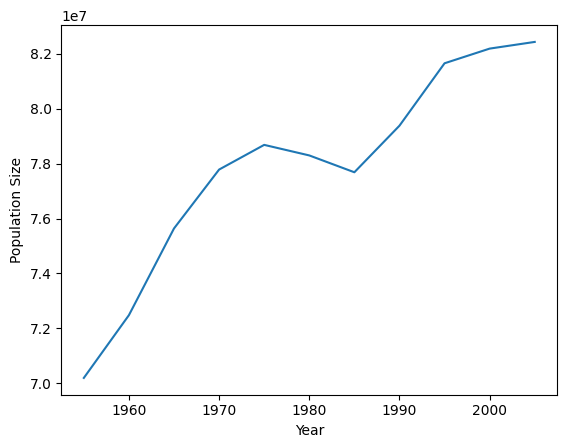

In [ ]:
plt.plot(df_ger['year'], df_ger['pop'])
plt.xlabel("Year")
plt.ylabel("Population Size")

**Exercise**: Plot the fertility rates (`"fertility"`) across time (`"year"`) for Germany (`df_ger`)

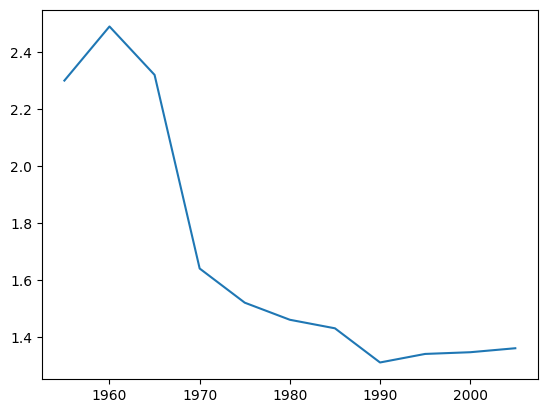

In [ ]:
plt.plot(df_ger['year'], df_ger['fertility'])

**Exercise**: Plot the fertility rates (`"fertility"`) across time (`"year"`) for Germany (`df_ger`) and set the `linewidth` to `2.5` and the color to green.

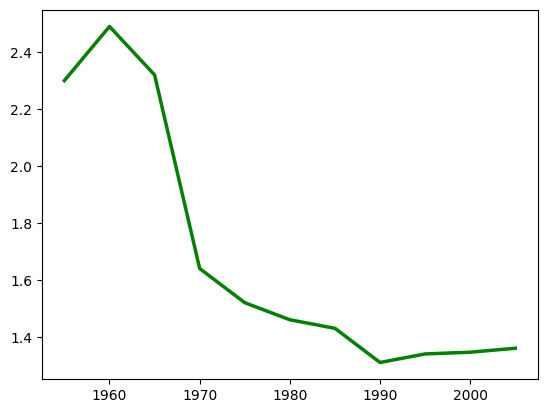

In [ ]:
plt.plot(df_ger['year'], df_ger['fertility'], color = 'g', linewidth = 2.5)

**Exercise**: Plot the fertility rates (`"fertility"`) across time (`"year"`) for the United States (`df_usa`) and add a `marker`.

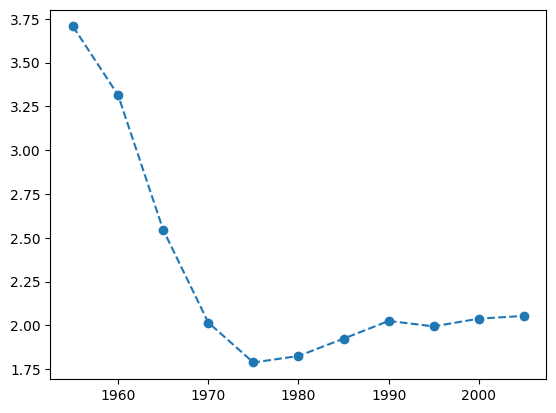

In [ ]:
plt.plot(df_usa['year'], df_usa['fertility'], linestyle = '--', marker = 'o')

**Exercise**: Plot the same data but add the labels `"Year"` and `"Fertility Rate"` to the x- and y-axis.

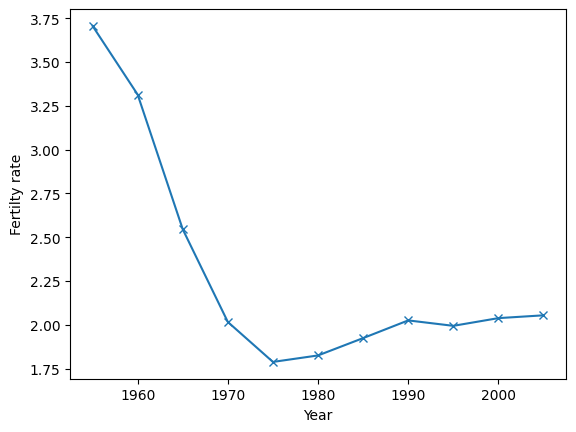

In [ ]:
plt.plot(df_usa['year'], df_usa['fertility'], marker = 'x')
plt.xlabel('Year')
plt.ylabel('Fertilty rate')

**Exercise**: Plot the fertility rates (`"fertility"`) across time (`"year"`) for Germany (`df_ger`) and the United States (`df_usa`) and label the x- and y-axis with `"Year"` and `"Fertility Rate"`. Add a `label` to each line and add a `plt.legend()`.

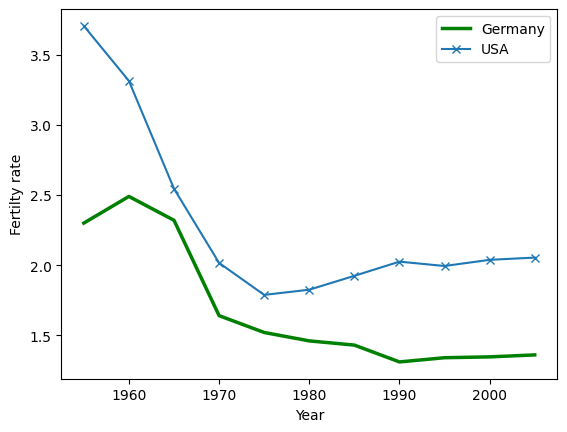

In [ ]:
plt.plot(df_ger['year'], df_ger['fertility'], color = 'g', linewidth = 2.5, label = 'Germany')
plt.plot(df_usa['year'], df_usa['fertility'], marker = 'x', label='USA')
plt.xlabel('Year')
plt.ylabel('Fertilty rate')
plt.legend()

## Creating Multiple Subplots

Often, we want to visualize different kinds of data side by side. For
example, in our example data set, it would be interesting to plot the
changes in fertility rate together with changes in population size. This
can be done with the `plt.subplot()` function. `plt.subplot` takes three
integer numbers as arguments. The first two numbers determine rows and
columns in the grid of subplots. The third number determines the
position of the current subplot in that grid, counting from left to
right and from top to bottom. To create multiple subplots, we call
`plt.subplot()` once, call the Matplotlib commands we want to execute
(e.g. `plt.plot()` or `plt.xlabel()`) and then call `plt.subplot()`
again to create the next one. Once we are done, we can save our result
to an image using the `plt.savefig()` function.

| Code | Description |
|------------------------------------|------------------------------------|
| `plt.subplots(2, 2, 1)` | Draw the first (i.e. upper left) subplot in a 2-by-2 grid |
| `plt.subplots(2, 2, 4)` | Draw the fourth (i.e. lower right) subplot in a 2-by-2 grid |
| `plt.tight_layout()` | Adjust the layout so that the subplots don’t overlap |
| `plt.savefig("myfig.png", dpi=300)` | Store the current figure as `"myfig.png"` with a resolution of 300 `dpi` (dots per inch) |

------------------------------------------------------------------------

#### **Exercises**

**Example**: Create a 2-by-2 grid of (empty) subplots

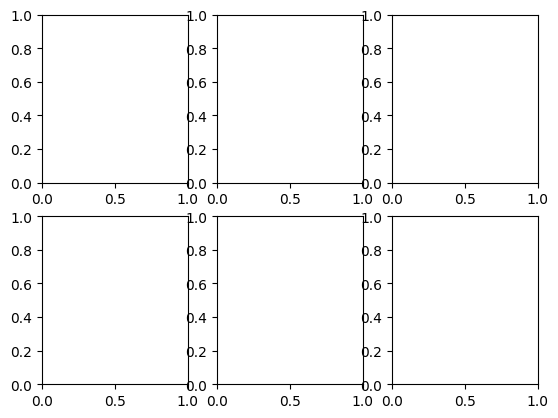

In [ ]:
plt.subplot(2,3,1)
plt.subplot(2,3,2)
plt.subplot(2,3,3)
plt.subplot(2,3,4)
plt.subplot(2,3,5)
plt.subplot(2,3,6)

**Example**: Create a 2-by-1 grid of (empty) subplots and label their x-axes as `"x1"` and `"x2"`.

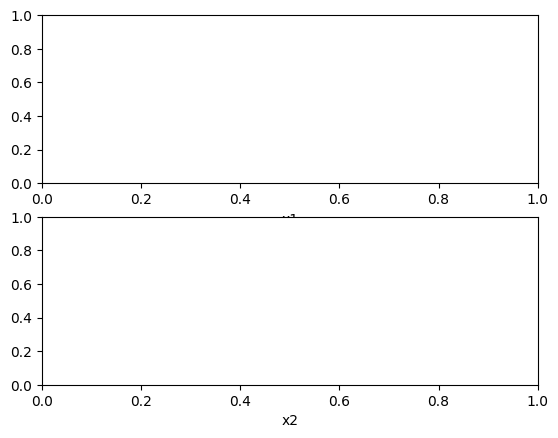

In [ ]:
plt.subplot(2,1,1)
plt.xlabel("x1")
plt.subplot(2,1,2)
plt.xlabel("x2")

**Exercise**: Create a 1-by-2 grid of (empty) subplots

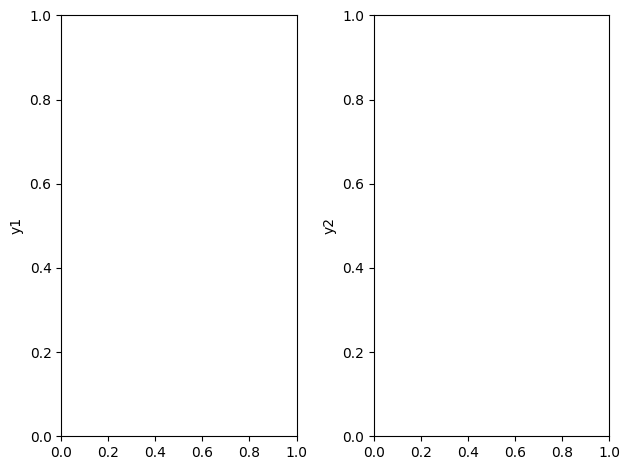

In [ ]:
plt.subplot(1,2,1)
plt.ylabel('y1')
plt.subplot(1,2,2)
plt.ylabel('y2')
plt.tight_layout()

**Exercise**: Create a 1-by-2 grid of subplots. On the first one, plot the `"fertility"` rate and, one the second one, the population size (`"pop"`) over time (`"year"`) for Germany (`df_ger`). Label the y-axes `"Fertility Rate"` and `"Population Size"` and the x-axes `"Year"`.

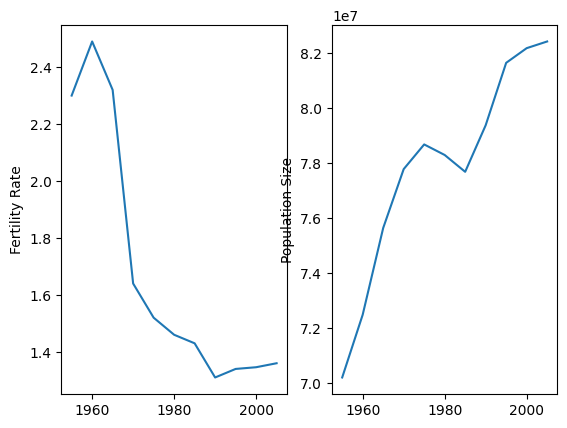

In [ ]:
plt.subplot(1,2,1)
plt.plot(df_ger['year'], df_ger['fertility'])
plt.ylabel('Fertility Rate')

plt.subplot(1,2,2)
plt.plot(df_ger['year'], df_ger['pop'])
plt.ylabel('Population Size')

**Exercise**: Re-create the plot from <a href="#exr-subplots" class="quarto-xref">Exercise 9</a> but call `plt.tight_layout()`.

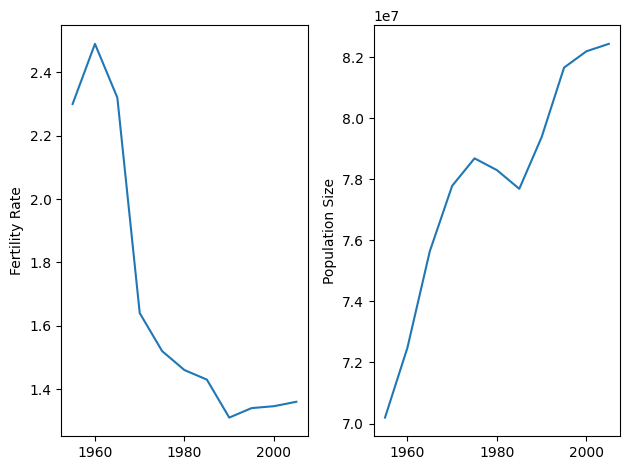

In [ ]:
plt.subplot(1,2,1)
plt.plot(df_ger['year'], df_ger['fertility'])
plt.ylabel('Fertility Rate')
plt.subplot(1,2,2)
plt.plot(df_ger['year'], df_ger['pop'])
plt.ylabel('Population Size')
plt.tight_layout()

**Exercise**: Create a 3-by-1 grid of subplots. On the first one, plot the `"fertility"` rate and, on the
second one, the population size (`"pop"`) and on the third one the life
expectancy (`"life_expect"`) over time (`"year"`) for the United States
(`df_usa`). Label the x-axes with `"Fertility Rate"`,
`"Population Size"` and `"Life Expectancy"`. Label the x-axis with
`"Year"`, only for the last subplot.

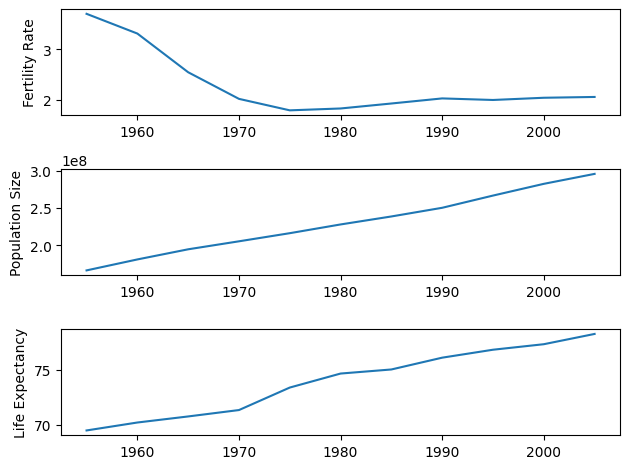

In [ ]:
plt.subplot(3,1,1)
plt.plot(df_usa['year'], df_usa['fertility'])
plt.ylabel('Fertility Rate')
plt.subplot(3,1,2)
plt.plot(df_usa['year'], df_usa['pop'])
plt.ylabel('Population Size')
plt.subplot(3,1,3)
plt.plot(df_usa['year'], df_usa['life_expect'])
plt.ylabel('Life Expectancy')
plt.tight_layout()

**Exercise**: Re-create the figure from <a href="#exr-us" class="quarto-xref">Exercise 11</a> and save it
to a file called `gapminder_us.png` with 300 `dpi`. Then, open the image
with your file browser to verify that the image was saved correctly.

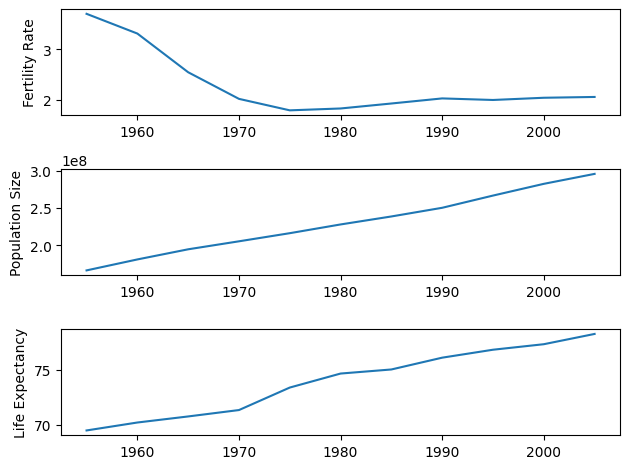

In [ ]:
plt.subplot(3,1,1)
plt.plot(df_usa['year'], df_usa['fertility'])
plt.ylabel('Fertility Rate')
plt.subplot(3,1,2)
plt.plot(df_usa['year'], df_usa['pop'])
plt.ylabel('Population Size')
plt.subplot(3,1,3)
plt.plot(df_usa['year'], df_usa['life_expect'])
plt.ylabel('Life Expectancy')
plt.tight_layout()

plt.savefig('gapminder_us.png', dpi=300)

## Plotting and Quantifying the Relationship between Variables

Visualizations are great for understanding the relationship between
variables. However, we also may want to quantify that relationship
statistically. A simple way to do this is to fit a linear model to the
data. The linear model describes the relationship between a dependent
variable `x` and an independent variable `y` as a line. That line has
two parameters: the intercept `a` and the slope `b`. `a` is the value of
`y` when `x==0` and `b` is the change in `y` that corresponds to a unit
change in `x`. In this section, we will use the `linregress()` function
from the `scipy.stats` module to model the relationship between life
expectancy and fertility in the Gapminder data set. Finally, we will
plot the estimated linear model together with the data.

| Code | Description |
|------------------------------------|------------------------------------|
| `plt.scatter(x, y)` | Create a scatter plot with points at the coordinates `x` and `y` |
| `from scipy.stats import linregress` | Import the `linregress` function from the `scipy` package |
| `results = linregress(x, y)` | Compute the linear regression between the variables x and y and assign the returned value to a variable `results` |

------------------------------------------------------------------------

#### **Exercises**

**Example**: Create a `scatter` plot to visualize the relationship between life expectancy (`"life_expect"`) and fertility rates (`"fertility"`) for the whole Gapminder data set (`df`) and label the axes with `"Life Expectancy in Years"` and `"Fertility Rate"`.

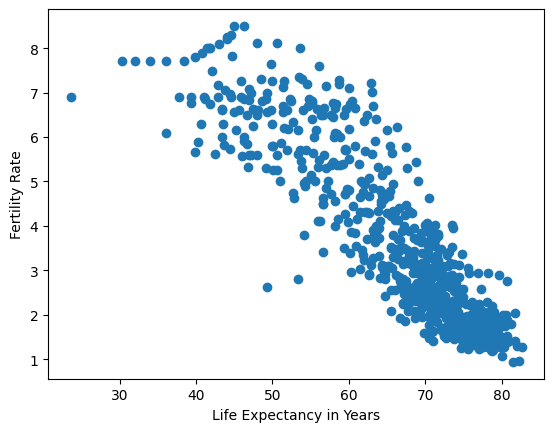

In [ ]:
plt.scatter(df['life_expect'], df['fertility'])
plt.xlabel('Life Expectancy in Years')
plt.ylabel('Fertility Rate')

Run the cell below to get the data for Asia and North America, respectively, and put them in separate data frames `df_asia` and `df_noram`.

In [ ]:
df_asia = df[df['continent'] == 'Asia']
df_noram = df[df['continent'] == 'North America']

**Exercise**: Create a `scatter` plot to visualize the relationship between life expectancy (`"life_expect"`) and fertility rates (`"fertility"`) for Asia (`df_asia`) and label the axes with `"Life Expectancy in Years"` and `"Fertility Rate"`.

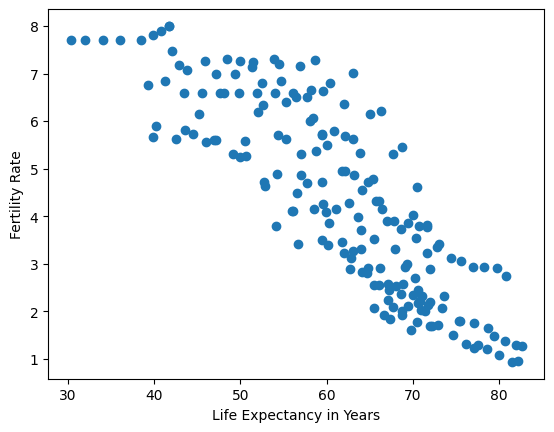

In [ ]:
plt.scatter(df_asia['life_expect'], df_asia['fertility'])
plt.xlabel('Life Expectancy in Years')
plt.ylabel('Fertility Rate')

**Exercise**: Create a `scatter` plot to visualize the relationship between life expectancy
(`"life_expect"`) and fertility rates (`"fertility"`) for **both** Asia (`df_asia`) and North America (`df_noram`) together in the same plot. Label the axes with
`"Life Expectancy in Years"` and `"Fertility Rate"`.

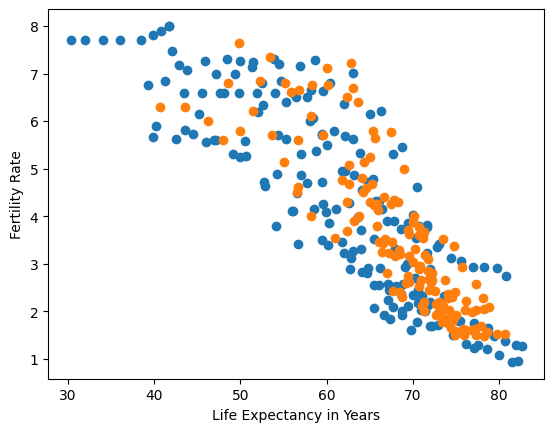

In [ ]:
plt.scatter(df_asia['life_expect'], df_asia['fertility'])
plt.scatter(df_noram['life_expect'], df_noram['fertility'])
plt.xlabel('Life Expectancy in Years')
plt.ylabel('Fertility Rate')

**Exercise**: Import the `linregress` function from the `scipy.stats` module.

In [ ]:
from scipy.stats import linregress

**Example**: Compute the linear regression between life expectancy (`"life_expect"`) and population size (`"pop"`) and store the returned value in a variable called `results`. Then, extract the p-value which is stored in the 4th element of `results`, assign it to a variable `p` and print that variable.

In [ ]:
results = linregress(df["life_expect"], df["pop"])
p = results[3]
p

0.10897571814366507

**Exercise**: Compute the linear regression between life expectancy (`"life_expect"`) and fertility rate (`"fertility"`) and store the returned value in a variable called `results`.
Then, extract the slope and intercept which are stored in the 1st and
2nd element of `results`, assign them to variables `slope` and `intercept` print
those variable.

In [ ]:
results = linregress(df["life_expect"], df["fertility"])
slope, intercept = results[0], results[1]
slope, intercept

(-0.1591172687736899, 14.130790658504012)

**Exercise**: Execute the cell below to create the `line()` function which takes in `x` values, the ``intercept``, and the ``slope``, and returns the corresponding y-values.
Then call `line()` and pass the life expectancy values in
`df["life_expect"]`, the ``intercept`` and the ``slope`` to obtain the
fertility rates predicted by the model. Store those in a new variable
called `fertility_pred`.

In [ ]:
def line(x, slope, intercept):
    """
    Return points on a line for the given x coordinates.
    Arguments:
        x: x-coordinates of the data points.
        a: intercept of the line.
        b: slope of the line.
    Returns:
        y: y-coordinates of the data point.
    """
    y = intercept + slope * x
    return y

In [ ]:
fertility_pred = line(df['life_expect'], slope, intercept)

**Exercise**: Plot the predicted fertility (`fertility_pred`) against the life expectance (`df['life_expect]`) in a standard line plot (`plt.plot()`). Label the x- and y-axis `"Life Expectancy in Years"` and `"Fertility Rate of the Population"`, respectively.

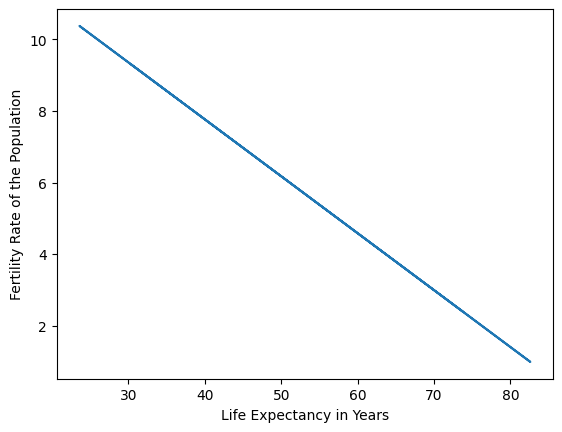

In [ ]:
plt.plot(df['life_expect'], fertility_pred)
plt.xlabel('Life Expectancy in Years')
plt.ylabel('Fertility Rate of the Population')

**Exercise**: Create a `scatter` plot to visualize the relationship between life expectancy (`"life_expect"`) and fertility rates (`"fertility"`). Then,
`plt.plot()` the predicted fertility rates against the life expectancy
in the same plot. Finally, label the axes with
`"Life Expectancy in Years"` and `"Fertility Rate"`.

**Hint**: Change the color of the predicted fertility line if it's hard to see.

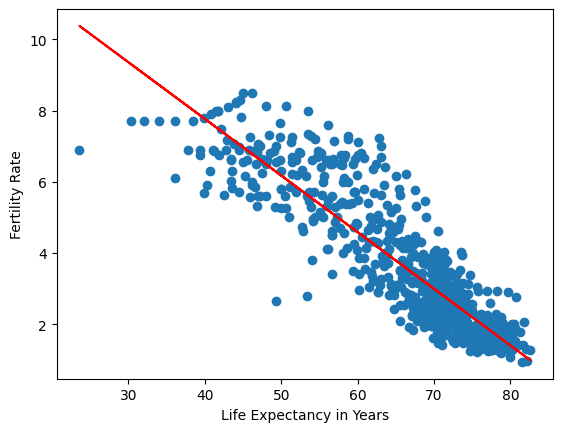

In [ ]:
plt.scatter(df['life_expect'], df['fertility'])
plt.plot(df['life_expect'], fertility_pred, 'r')
plt.xlabel('Life Expectancy in Years')
plt.ylabel('Fertility Rate')

## Combining Matplotlib with Seaborn

Matplotlib takes an **imperative** approach to visualization where we
specify exactly what we want to draw. This provides fine-grained control
but also requires you to write more code. In contrast, Seaborn takes a
more **declarative** approach where we specify what data we want to
visualize. This allows us to create detailed visualizations without
having to worry about the low level implementation. Finally, we can
combine the advantages both approaches and use Seaborn to create and
Matplotlib to customize our visualizations. In this section, we will use
Seaborn to create detailed visualizations of the Gapminder data. Then,
we’ll plot these visualizations to subplots created with Matplotlib and
customize them.

| Code | Description |
|------------------------------------|------------------------------------|
| `sns.kdeplot(data=df, x="var1", hue="var2")` | Plot the kernel density estimate (kde) for variable `"var1"` from `df` and add a `hue` to encode `"var2"` |
| `sns.scatterplot(data=df, x="var1", y="var2", hue="var3")` | Plot `"var1"` against `"var2"` in a `scatterplot` and add a `hue` to encode `"var3"` |
| `ax1 = plt.subplot(1,2,1)` | Create the first `subplot` in a 1-by-2 grid and assign the returned object to a variable `ax1` |
| `sns.scatterplot(data=df, x="var1", y="var2", ax=ax1)` | Plot `"var1"` against `"var2"` in a `scatterplot` on subplot `ax1` |
| `ax1.annotate("X", xy=(0.5,0.5), xycoords="axes fraction", fontsize = 18)` | Plot the letter `"X"` on subplot `ax1` at `xy` coordinates `(0.5,0.5)` defined in fractions of an axis (i.e. in the middle of the plot). Fontsize is an optional argument. |

------------------------------------------------------------------------

**Exercise**: Import the `seaborn` library under the alias `sns`

In [ ]:
import seaborn as sns

**Exercise**: Create a `sns.scatterplot()` to visualize the relationship between life expectancy (`"life_expect"`) and `"fertility"` rates for the Gapminder
data and add `hue` to encode the `"continent"`.

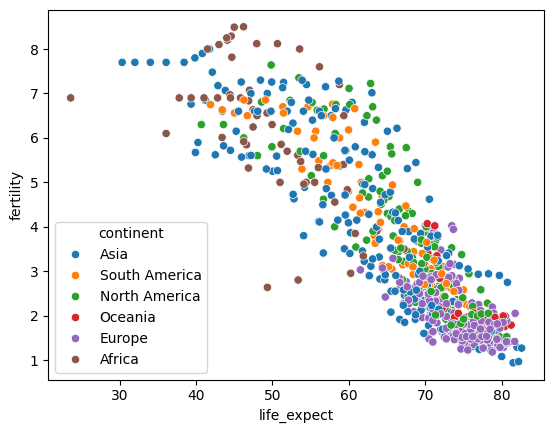

In [ ]:
sns.scatterplot(df, x = 'life_expect', y = 'fertility', hue = 'continent')

**Exercise**: Create a `sns.kdeplot()` (kernel density estimate) to visualize the global distribution for `"fertility"` rates and add `hue` to encode the
`"year"`.

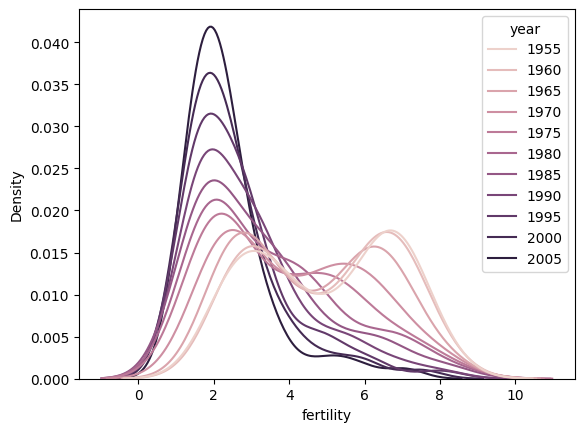

In [ ]:
sns.kdeplot(df, x = 'fertility', hue='year')

**Example**: Create the first subplot in a 1-by-2 grid and assign the returned axes object to a variable called `ax1`. Then, create the scatter plot from <a href="#exr-sns_scatter" class="quarto-xref">Exercise 20</a> and draw it to the subplot by using the `ax` argument of `sns.scatterplot()`.

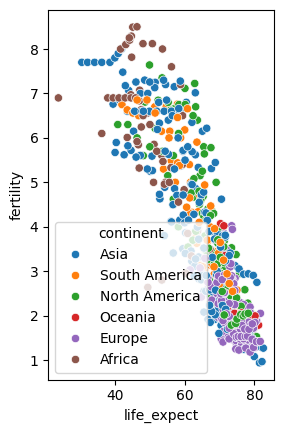

In [ ]:
ax1 = plt.subplot(1,2,1)
sns.scatterplot(x=df["life_expect"], y=df["fertility"], hue=df["continent"], ax=ax1)

**Exercise**: Create two subplots in a 1-by-2 grid and assign the returned axes to two variables `ax1` and `ax2`. Then, create the scatter plot from <a href="#exr-sns_scatter" class="quarto-xref">Exercise 20</a> and the kde plot from <a href="#exr-sns_kde" class="quarto-xref">Exercise 21</a> and draw them to the subplots `ax1` and `ax2` by using the `ax` argument of `sns.scatterplot()` and `sns.kdeplot()`. Use `plt.tight_layout()` if necessary.

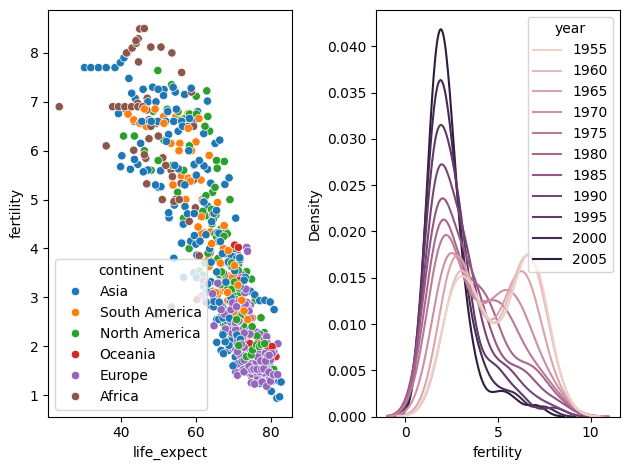

In [ ]:
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

sns.scatterplot(x=df["life_expect"], y=df["fertility"], hue=df["continent"], ax=ax1)
sns.kdeplot(df, x = 'fertility', hue='year', ax = ax2)

plt.tight_layout()

**Exercise**: Re-create the figure from <a href="#exr-sns_subplots" class="quarto-xref">Exercise 22</a> and use the `.set()` method to set the `xlabel` and `ylabel` of the scatter plot to `"Life Expectancy in Years"` and `"Fertility Rate"` and set the `xlabel` of the kde plot to `"Fertility Rate"`.

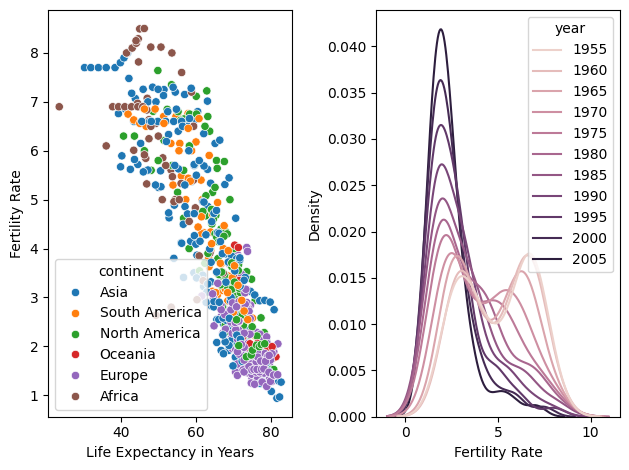

In [ ]:
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

sns.scatterplot(x=df["life_expect"], y=df["fertility"], hue=df["continent"], ax=ax1)
sns.kdeplot(df, x = 'fertility', hue='year', ax = ax2)

ax1.set(xlabel='Life Expectancy in Years', ylabel='Fertility Rate')
ax2.set(xlabel='Fertility Rate', ylabel='Density')

plt.tight_layout()

**Exercise**: Re-create the plot from <a href="#exr-sns_labels" class="quarto-xref">Exercise 23</a> and use the `.annotate()` method to draw the letters `"A"` and `"B"` in the top left corner of the subplots.

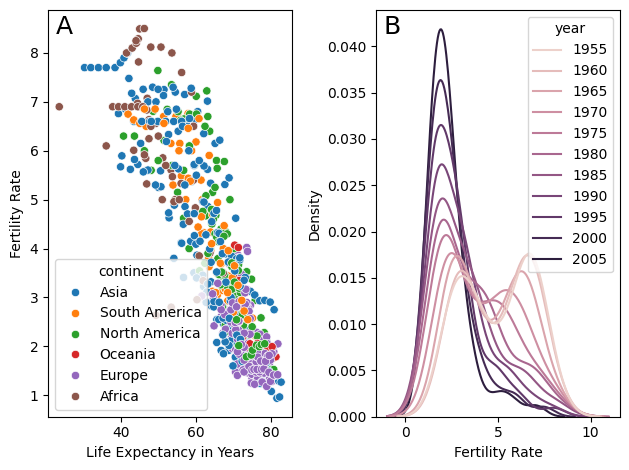

In [ ]:
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

sns.scatterplot(x=df["life_expect"], y=df["fertility"], hue=df["continent"], ax=ax1)
sns.kdeplot(df, x = 'fertility', hue='year', ax = ax2)

ax1.set(xlabel='Life Expectancy in Years', ylabel='Fertility Rate')
ax2.set(xlabel='Fertility Rate', ylabel='Density')

ax1.annotate('A', xy=[0.03,0.94], xycoords="axes fraction", fontsize = 18)
ax2.annotate('B', xy=[0.03,0.94], xycoords="axes fraction", fontsize = 18)

plt.tight_layout()